In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from datasets import load_dataset

column_names = ['label', 'text']

train_df = pd.read_csv('/kaggle/input/datasets/irustandi/yelp-review-polarity/yelp_review_polarity_csv/train.csv', header=None, names=column_names)
test_df = pd.read_csv('/kaggle/input/datasets/irustandi/yelp-review-polarity/yelp_review_polarity_csv/test.csv', header=None, names=column_names)

train_df['label'] = train_df['label'] - 1
test_df['label'] = test_df['label'] - 1

train_df = train_df.sample(n=100000, random_state=42)
test_df = test_df.sample(n=10000, random_state=42)

print(f"Дані завантажено. Тренувальна вибірка: {train_df.shape}")
print(train_df['label'].value_counts())

Дані завантажено. Тренувальна вибірка: (100000, 2)
label
0    50229
1    49771
Name: count, dtype: int64


In [14]:
vocab_size = 20000
max_length = 150
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['text'])

training_sequences = tokenizer.texts_to_sequences(df['text'])
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(df_test['text'])
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

training_labels = np.array(df['label'])
testing_labels = np.array(df_test['label'])

print("Текст успішно токенізовано та доповнено (padded).")

Текст успішно токенізовано та доповнено (padded).


In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
num_epochs = 5
history = model.fit(
    training_padded, 
    training_labels, 
    epochs=num_epochs, 
    validation_data=(testing_padded, testing_labels),
    batch_size=64,
    verbose=1
)

Epoch 1/5
627/627 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.7653 - loss: 0.4622 - val_accuracy: 0.8857 - val_loss: 0.2877
Epoch 2/5
627/627 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9322 - loss: 0.1838 - val_accuracy: 0.8977 - val_loss: 0.2601
Epoch 3/5
627/627 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9557 - loss: 0.1294 - val_accuracy: 0.8934 - val_loss: 0.2766
Epoch 4/5
627/627 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9703 - loss: 0.0924 - val_accuracy: 0.8932 - val_loss: 0.3198
Epoch 5/5
627/627 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9809 - loss: 0.0582 - val_accuracy: 0.8897 - val_loss: 0.4745


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Accuracy: 0.8897
Precision: 0.9059
Recall: 0.8495
F1-Score: 0.8768


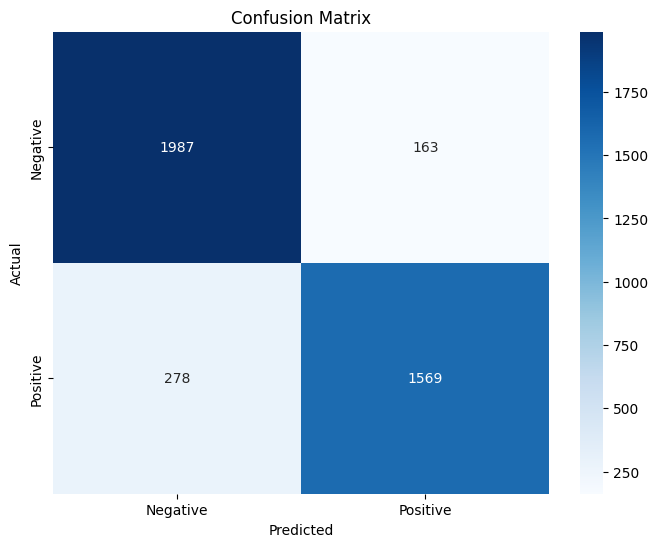

In [17]:
predictions = (model.predict(testing_padded) > 0.5).astype("int32")

acc = accuracy_score(testing_labels, predictions)
prec = precision_score(testing_labels, predictions)
rec = recall_score(testing_labels, predictions)
f1 = f1_score(testing_labels, predictions)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(testing_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [18]:
def predict_sentiment(text):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_length, padding=padding_type, truncating=trunc_type)
    
    prediction = model.predict(padded)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    
    return sentiment, confidence

test_texts = [
    "The food was absolutely amazing and the service was top-notch!", # Позитивний
    "I hated this place. The staff was rude and the table was dirty.", # Негативний
    "It was okay, but I've had better burgers elsewhere.",            # Нейтрально-негативний
    "Fantastic experience, highly recommend to everyone!"             # Новий текст
]

print("-" * 30)
for text in test_texts:
    sentiment, conf = predict_sentiment(text)
    print(f"Text: {text}\nSentiment: {sentiment} ({conf:.2%})\n")

------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Text: The food was absolutely amazing and the service was top-notch!
Sentiment: Positive (99.99%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Text: I hated this place. The staff was rude and the table was dirty.
Sentiment: Negative (99.99%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Text: It was okay, but I've had better burgers elsewhere.
Sentiment: Negative (99.88%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Text: Fantastic experience, highly recommend to everyone!
Sentiment: Positive (99.96%)

